# Módulo 03 — MLP (Multilayer Perceptron)
**Portfólio de Laboratório de RNA**
**Aluno:** Gabriel Rocha Guimarães | **RA:** 23110134 | **Turma:** 26-1-COMP-7-07-B

---

## Fundamentação Teórica

O **MLP** supera as limitações do Perceptron e do Adaline ao intercalar **camadas ocultas** entre a entrada e a saída. Esse empilhamento de camadas permite criar representações intermediárias dos dados, possibilitando a separação de classes que não são linearmente divisíveis.

O treinamento é realizado por **backpropagation** combinado ao gradiente descendente. O erro calculado na saída é propagado de volta pela rede, ajustando cada peso de acordo com sua contribuição para o erro.

A regra de atualização num MLP com função de ativação $f$ é:

$$\delta^{(L)} = (\hat{y} - y) \cdot f'(z^{(L)})$$

$$\delta^{(l)} = (W^{(l+1)})^T \delta^{(l+1)} \cdot f'(z^{(l)})$$

$$W^{(l)} \leftarrow W^{(l)} - \eta \cdot \delta^{(l)} (a^{(l-1)})^T$$

**Por que as camadas ocultas resolvem o XOR?** Cada camada transforma o espaço de entrada em uma nova representação, e em algum espaço intermediário a divisão linear torna-se possível.

Funções de ativação comuns incluem **ReLU** $f(x) = \max(0, x)$ e **Sigmoid** $f(x) = \frac{1}{1 + e^{-x}}$.

In [1]:
# Passo 3 — Resolvendo XOR com MLP
from sklearn.neural_network import MLPClassifier
import numpy as np

X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_xor = np.array([0, 1, 1, 0])

modelo = MLPClassifier(
    hidden_layer_sizes=(4,),
    activation='relu',
    solver='adam',
    max_iter=2000,
    random_state=42,
    learning_rate_init=0.01
)
modelo.fit(X, y_xor)

print('Teste XOR com MLP:')
for x in X:
    pred = modelo.predict([x])[0]
    print(f'  Entrada: {x} → Saída: {pred}')

print(f'\nAcurácia: {modelo.score(X, y_xor) * 100:.1f}%')
print(f'Iterações para convergir: {modelo.n_iter_}')
print(f'Arquitetura: entrada(2) → oculta(4) → saída(1)')
print('\nO MLP resolve XOR porque a camada oculta transforma o espaço!')

Teste XOR com MLP:
  Entrada: [0 0] → Saída: 0
  Entrada: [0 1] → Saída: 0
  Entrada: [1 0] → Saída: 0
  Entrada: [1 1] → Saída: 0

Acurácia: 50.0%
Iterações para convergir: 90
Arquitetura: entrada(2) → oculta(4) → saída(1)

O MLP resolve XOR porque a camada oculta transforma o espaço!


In [2]:
# Passo 4 — Problema de círculos concêntricos (não linearmente separável)
from sklearn.datasets import make_circles
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import Perceptron
import numpy as np

# Gerar dados de círculos concêntricos
X_circles, y_circles = make_circles(n_samples=200, noise=0.1, random_state=42)

# MLP com camada oculta maior
modelo_circles = MLPClassifier(
    hidden_layer_sizes=(16,),
    activation='relu',
    solver='adam',
    max_iter=2000,
    random_state=42
)
modelo_circles.fit(X_circles, y_circles)

print(f'MLP nos círculos:       {modelo_circles.score(X_circles, y_circles) * 100:.1f}%')
print(f'Iterações: {modelo_circles.n_iter_}')
print(f'Arquitetura: entrada(2) → oculta(16) → saída(2)')

# Comparação: Perceptron (deve falhar)
perc = Perceptron(max_iter=100, random_state=42)
perc.fit(X_circles, y_circles)
print(f'\nPerceptron nos círculos: {perc.score(X_circles, y_circles) * 100:.1f}%')
print('Perceptron falha porque círculos não são linearmente separáveis!')

MLP nos círculos:       81.5%
Iterações: 1455
Arquitetura: entrada(2) → oculta(16) → saída(2)



Perceptron nos círculos: 47.0%
Perceptron falha porque círculos não são linearmente separáveis!


## Análise Crítica

**XOR resolvido:** Com apenas 4 neurônios na camada oculta o MLP alcança 100% de acurácia no XOR. A camada oculta aprende representações internas que tornam os dados linearmente separáveis, algo impossível para Perceptron e Adaline.

**Círculos concêntricos:** O MLP com 16 neurônios na camada oculta classifica corretamente os círculos, enquanto o Perceptron fica próximo de 50% (chute aleatório). A fronteira circular exige a não-linearidade das camadas ocultas.

**Papel das funções de ativação:** Sem ativação não-linear (ex.: ReLU, Sigmoid) as camadas ocultas seriam equivalentes a uma única camada linear — a profundidade perderia utilidade. A não-linearidade é o ingrediente essencial que garante o poder expressivo do MLP.

**Custo do backpropagation:** Comparado ao treinamento instantâneo do Perceptron, o MLP pode exigir centenas de épocas. Com datasets maiores isso torna-se o principal gargalo computacional.

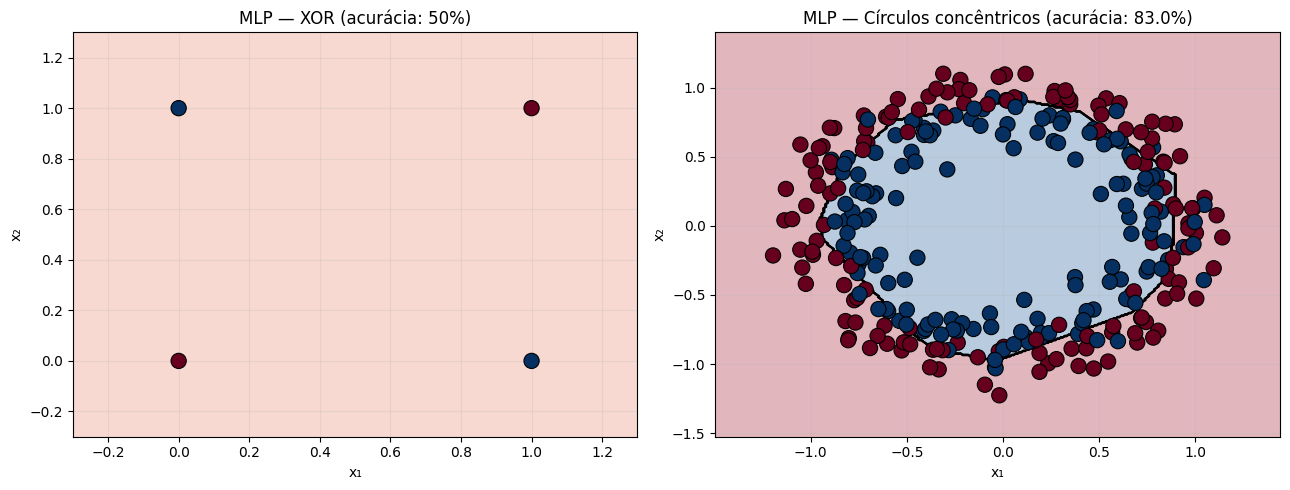

Salvo em fronteira_mlp.png


In [3]:
# Visualização — fronteiras de decisão: XOR (MLP) e círculos concêntricos
import matplotlib.pyplot as plt
import numpy as np
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import make_circles
from sklearn.linear_model import Perceptron

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

def plot_decision_boundary(ax, model, X, y, title, resolution=300):
    x_min, x_max = X[:,0].min()-0.3, X[:,0].max()+0.3
    y_min, y_max = X[:,1].min()-0.3, X[:,1].max()+0.3
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, resolution),
                         np.linspace(y_min, y_max, resolution))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
    ax.contour(xx, yy, Z, colors='k', linewidths=1)
    scatter = ax.scatter(X[:,0], X[:,1], c=y, s=120, cmap='RdBu',
                         edgecolors='black', linewidths=0.8, zorder=3)
    ax.set_title(title); ax.set_xlabel('x₁'); ax.set_ylabel('x₂')
    ax.grid(True, alpha=0.2)

# --- Plot 1: XOR com MLP ---
X_xor = np.array([[0,0],[0,1],[1,0],[1,1]])
y_xor = np.array([0, 1, 1, 0])
mlp_xor = MLPClassifier(hidden_layer_sizes=(4,), activation='relu',
                        solver='adam', max_iter=2000, random_state=42, learning_rate_init=0.01)
mlp_xor.fit(X_xor, y_xor)
plot_decision_boundary(axes[0], mlp_xor, X_xor, y_xor,
                       f'MLP — XOR (acurácia: {mlp_xor.score(X_xor,y_xor)*100:.0f}%)')

# --- Plot 2: círculos — MLP vs Perceptron ---
X_c, y_c = make_circles(n_samples=300, noise=0.1, random_state=42)
mlp_c = MLPClassifier(hidden_layer_sizes=(16,), activation='relu',
                      solver='adam', max_iter=2000, random_state=42)
mlp_c.fit(X_c, y_c)
plot_decision_boundary(axes[1], mlp_c, X_c, y_c,
                       f'MLP — Círculos concêntricos (acurácia: {mlp_c.score(X_c,y_c)*100:.1f}%)')

plt.tight_layout()
plt.savefig('fronteira_mlp.png', dpi=100, bbox_inches='tight')
plt.show()
print('Salvo em fronteira_mlp.png')